# Superstore Sales & Profitability Analysis

**Goal:** figure out where a US retail superstore chain is making money, where it's quietly losing money, and what leadership should do about it.

**Dataset:** [Sample Superstore](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) (Kaggle) — 9,994 US retail order line items, Jan 2015 – Dec 2018, covering Sales, Profit, Discount, Category, Region, Customer Segment and Shipping details.

**Approach:** the analysis is split into three passes, deliberately mirroring how I'd approach this in an enterprise reporting environment:

1. **Data quality checks** — validate the raw extract before trusting a single number.
2. **SQL-based analysis** — the same aggregation/ranking logic I'd write as SQLScript against a HANA calculation view, run here with SQLite so the notebook is self-contained.
3. **Exploratory & visual analysis** — turn the numbers into charts and plain-language recommendations for a business audience.


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {
    "sales": "#4C72B0",
    "profit_pos": "#2E7D32",
    "profit_neg": "#C0392B",
    "accent": "#DD8452",
}
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Data Loading & Quality Checks

Before computing a single KPI, the raw extract gets the same treatment I'd give an incoming data load in a production HANA model: check row counts, check for structurally broken rows, and reconcile against what's expected.


In [2]:
raw = pd.read_csv("../data/Sample-Superstore.csv", encoding="latin1")
print(f"Raw rows: {len(raw):,}  |  Columns: {raw.shape[1]}")
raw.isna().sum().to_frame("null_count").query("null_count > 0")


Raw rows: 10,800  |  Columns: 21


,null_count
Order Date,806
Ship Date,806
Ship Mode,806
Customer ID,806
Customer Name,806
Segment,806
Country,806
City,806
State,806
Postal Code,817


**Finding:** 806 rows are missing every core field (Order Date, Sales, Profit, Category, …) except `Order ID` and a `Row ID` of `"Yes"`. That's not real missing business data — it's a structurally broken tail appended by this CSV export (a leftover from a second sheet in the source workbook). The fix is to drop them at the source rather than let them silently deflate every downstream average.


In [3]:
malformed = raw[raw["Order Date"].isna()]
df = raw.dropna(subset=["Order Date"]).copy()

print(f"Dropped {len(malformed)} malformed rows -> {len(df):,} clean order line items")
assert df.duplicated().sum() == 0, "Unexpected duplicate rows after cleaning"
print("Duplicate rows:", df.duplicated().sum())


Dropped 806 malformed rows -> 9,994 clean order line items
Duplicate rows: 0


In [4]:
# Type casting & derived fields
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")
df["Postal Code"] = df["Postal Code"].astype("Int64")

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.to_period("M").astype(str)
df["Profit Margin"] = df["Profit"] / df["Sales"]
df["Processing Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print(f"Date range: {df['Order Date'].min().date()} -> {df['Order Date'].max().date()}")
print(f"Orders: {df['Order ID'].nunique():,}  |  Customers: {df['Customer ID'].nunique():,}  |  Line items: {len(df):,}")


Date range: 2015-01-03 -> 2018-12-30
Orders: 5,009  |  Customers: 793  |  Line items: 9,994


## 2. Headline KPIs


In [5]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
overall_margin = total_profit / total_sales
avg_discount = df["Discount"].mean()

kpis_display = pd.Series({
    "Total Sales": f"${total_sales:,.0f}",
    "Total Profit": f"${total_profit:,.0f}",
    "Overall Profit Margin": f"{overall_margin:.1%}",
    "Total Orders": f"{df['Order ID'].nunique():,}",
    "Total Customers": f"{df['Customer ID'].nunique():,}",
    "Average Discount": f"{avg_discount:.1%}",
})
kpis_display.to_frame("Value")


,Value
Total Sales,"$2,297,201"
Total Profit,"$286,397"
Overall Profit Margin,12.5%
Total Orders,"5,009"
Total Customers,793
Average Discount,15.6%


## 3. SQL-Based Analysis

The cleaned dataframe is loaded into an in-memory SQLite database so the same window-function / CTE patterns used against HANA calculation views can be demonstrated directly against this dataset.


In [6]:
conn = sqlite3.connect(":memory:")
df.to_sql("orders", conn, index=False, if_exists="replace")

def q(sql):
    return pd.read_sql_query(sql, conn)


### 3.1 Sales & profit by category (baseline aggregation)

In [7]:
q('''
SELECT
    Category,
    ROUND(SUM(Sales), 0)  AS total_sales,
    ROUND(SUM(Profit), 0) AS total_profit,
    ROUND(SUM(Profit) * 1.0 / SUM(Sales), 4) AS profit_margin
FROM orders
GROUP BY Category
ORDER BY total_sales DESC;
''')


,Category,total_sales,total_profit,profit_margin
0,Technology,"836,154.00","145,455.00",0.17
1,Furniture,"742,000.00","18,451.00",0.02
2,Office Supplies,"719,047.00","122,491.00",0.17


### 3.2 Ranking sub-categories within each region (window function)

`RANK() OVER (PARTITION BY ... ORDER BY ...)` — the same pattern used for "top-N per group" reporting requirements against a HANA model.


In [8]:
q('''
WITH sub_region AS (
    SELECT
        Region,
        [Sub-Category] AS sub_category,
        SUM(Profit) AS total_profit
    FROM orders
    GROUP BY Region, [Sub-Category]
),
ranked AS (
    SELECT
        Region,
        sub_category,
        ROUND(total_profit, 0) AS total_profit,
        RANK() OVER (PARTITION BY Region ORDER BY total_profit DESC) AS profit_rank
    FROM sub_region
)
SELECT * FROM ranked
WHERE profit_rank <= 3
ORDER BY Region, profit_rank;
''')


,Region,sub_category,total_profit,profit_rank
0,Central,Copiers,"15,609.00",1
1,Central,Phones,"12,323.00",2
2,Central,Accessories,"7,252.00",3
3,East,Copiers,"17,023.00",1
4,East,Phones,"12,315.00",2
5,East,Binders,"11,268.00",3
6,South,Phones,"10,767.00",1
7,South,Accessories,"7,005.00",2
8,South,Chairs,"6,612.00",3
9,West,Copiers,"19,327.00",1


### 3.3 Monthly sales with a running total (CTE + window function)


In [9]:
q('''
WITH monthly AS (
    SELECT
        strftime('%Y-%m', [Order Date]) AS order_month,
        SUM(Sales) AS monthly_sales
    FROM orders
    GROUP BY order_month
)
SELECT
    order_month,
    ROUND(monthly_sales, 0) AS monthly_sales,
    ROUND(SUM(monthly_sales) OVER (ORDER BY order_month), 0) AS running_total_sales
FROM monthly
ORDER BY order_month
LIMIT 12;
''')


,order_month,monthly_sales,running_total_sales
0,2015-01,"14,237.00","14,237.00"
1,2015-02,"4,520.00","18,757.00"
2,2015-03,"55,691.00","74,448.00"
3,2015-04,"28,295.00","102,743.00"
4,2015-05,"23,648.00","126,391.00"
5,2015-06,"34,595.00","160,987.00"
6,2015-07,"33,946.00","194,933.00"
7,2015-08,"27,909.00","222,842.00"
8,2015-09,"81,777.00","304,620.00"
9,2015-10,"31,453.00","336,073.00"


### 3.4 Loss-making customers (`HAVING` on an aggregate)

Flags accounts where cumulative profit across every order is negative — the kind of exception list that used to get raised as a production data/reporting issue and traced back to root cause.


In [10]:
loss_customers = q('''
SELECT
    [Customer ID]   AS customer_id,
    [Customer Name] AS customer_name,
    ROUND(SUM(Sales), 0)  AS total_sales,
    ROUND(SUM(Profit), 0) AS total_profit
FROM orders
GROUP BY customer_id, customer_name
HAVING total_profit < 0
ORDER BY total_profit ASC;
''')
print(f"{len(loss_customers)} of {df['Customer ID'].nunique()} customers are net loss-making")
loss_customers.head(10)


154 of 793 customers are net loss-making


,customer_id,customer_name,total_sales,total_profit
0,CS-12505,Cindy Stewart,"5,690.00","-6,626.00"
1,GT-14635,Grant Thornton,"9,351.00","-4,109.00"
2,LF-17185,Luke Foster,"3,931.00","-3,584.00"
3,SR-20425,Sharelle Roach,"3,233.00","-3,334.00"
4,HG-14965,Henry Goldwyn,"3,248.00","-2,798.00"
5,NC-18415,Nathan Cano,"2,219.00","-2,205.00"
6,SB-20290,Sean Braxton,"8,058.00","-2,083.00"
7,SM-20320,Sean Miller,"25,043.00","-1,981.00"
8,CP-12340,Christine Phan,"5,888.00","-1,850.00"
9,NF-18385,Natalie Fritzler,"8,323.00","-1,696.00"


## 4. Exploratory & Visual Analysis


### 4.1 Sales vs. profit by category

Furniture generates almost as much revenue as Technology, but converts less than a seventh of it to profit.


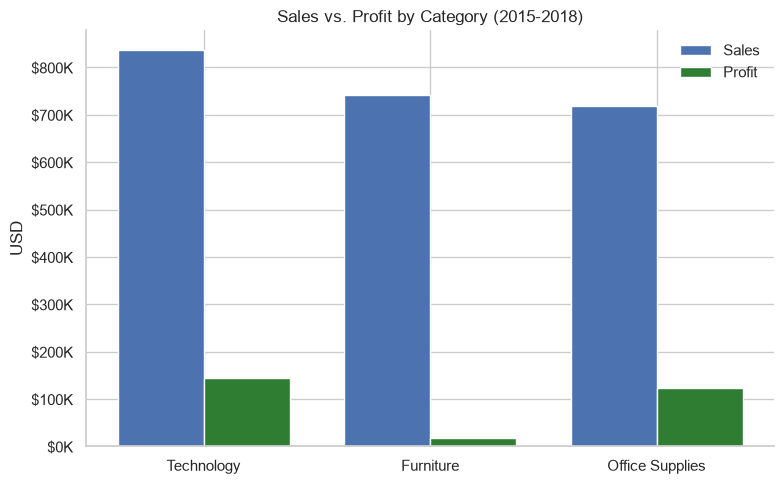

In [11]:
cat = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(cat))
width = 0.38
ax.bar(x - width/2, cat["Sales"], width, label="Sales", color=PALETTE["sales"])
ax.bar(x + width/2, cat["Profit"], width, label="Profit", color=PALETTE["profit_pos"])
ax.set_xticks(x)
ax.set_xticklabels(cat.index)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
ax.set_title("Sales vs. Profit by Category (2015-2018)")
ax.set_ylabel("USD")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig("../images/sales_profit_by_category.png", dpi=150)
plt.show()


### 4.2 Which sub-categories actually lose money?

Tables, Bookcases and Supplies run at a net loss across the full period — Tables alone gives back **$17.7K** on **$207K** of sales.


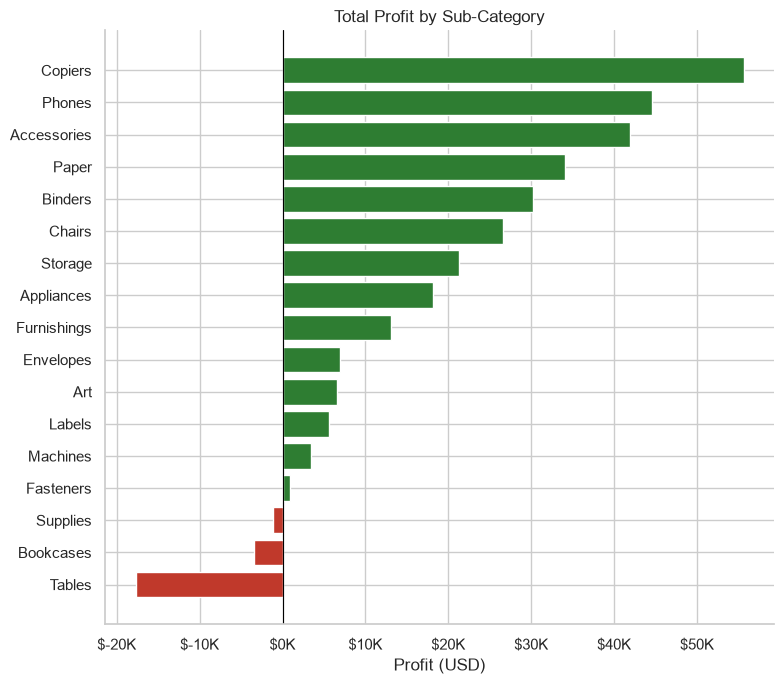

In [12]:
sub = df.groupby("Sub-Category")["Profit"].sum().sort_values()
colors = [PALETTE["profit_neg"] if v < 0 else PALETTE["profit_pos"] for v in sub.values]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(sub.index, sub.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
ax.set_title("Total Profit by Sub-Category")
ax.set_xlabel("Profit (USD)")
sns.despine()
plt.tight_layout()
plt.savefig("../images/subcategory_profit.png", dpi=150)
plt.show()


### 4.3 The discount cliff

Average profit margin by discount band. Margin holds up fine up to a ~20% discount, then falls off a cliff — discounts above 30% are, on average, sold at a loss.


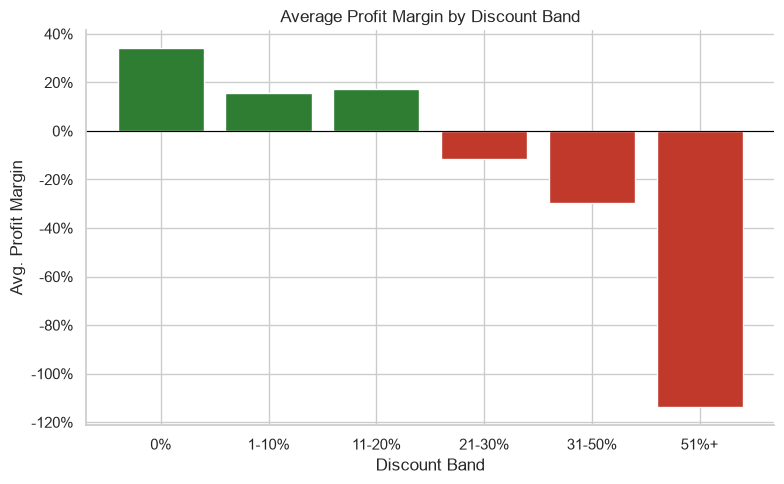

In [13]:
df["Discount Band"] = pd.cut(
    df["Discount"],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
    labels=["0%", "1-10%", "11-20%", "21-30%", "31-50%", "51%+"],
)
band_margin = df.groupby("Discount Band", observed=True)["Profit Margin"].mean()
colors = [PALETTE["profit_neg"] if v < 0 else PALETTE["profit_pos"] for v in band_margin.values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(band_margin.index.astype(str), band_margin.values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Average Profit Margin by Discount Band")
ax.set_xlabel("Discount Band")
ax.set_ylabel("Avg. Profit Margin")
sns.despine()
plt.tight_layout()
plt.savefig("../images/discount_cliff.png", dpi=150)
plt.show()


### 4.4 Regional performance

The West region converts sales to profit at nearly **2x** the rate of Central.


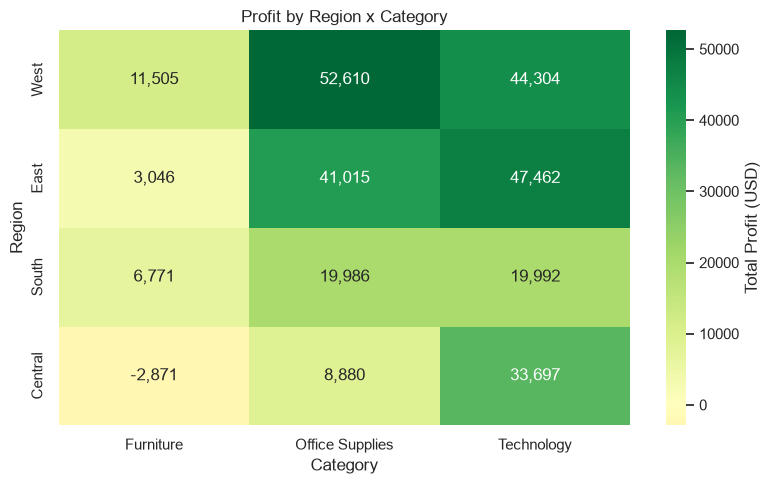

,Sales,Profit,Margin
Region,,,
West,"$725,458","$108,418",14.9%
East,"$678,781","$91,523",13.5%
South,"$391,722","$46,749",11.9%
Central,"$501,240","$39,706",7.9%


In [14]:
reg = df.groupby("Region")[["Sales", "Profit"]].sum()
reg["Margin"] = reg["Profit"] / reg["Sales"]
reg = reg.sort_values("Margin", ascending=False)

pivot = df.pivot_table(index="Region", columns="Category", values="Profit", aggfunc="sum")
pivot = pivot.loc[reg.index]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="RdYlGn", center=0, ax=ax, cbar_kws={"label": "Total Profit (USD)"})
ax.set_title("Profit by Region x Category")
plt.tight_layout()
plt.savefig("../images/regional_heatmap.png", dpi=150)
plt.show()

reg.style.format({"Sales": "${:,.0f}", "Profit": "${:,.0f}", "Margin": "{:.1%}"})


### 4.5 Monthly sales trend & seasonality

Sales trend upward year over year, with a sharp seasonal peak every November-December.


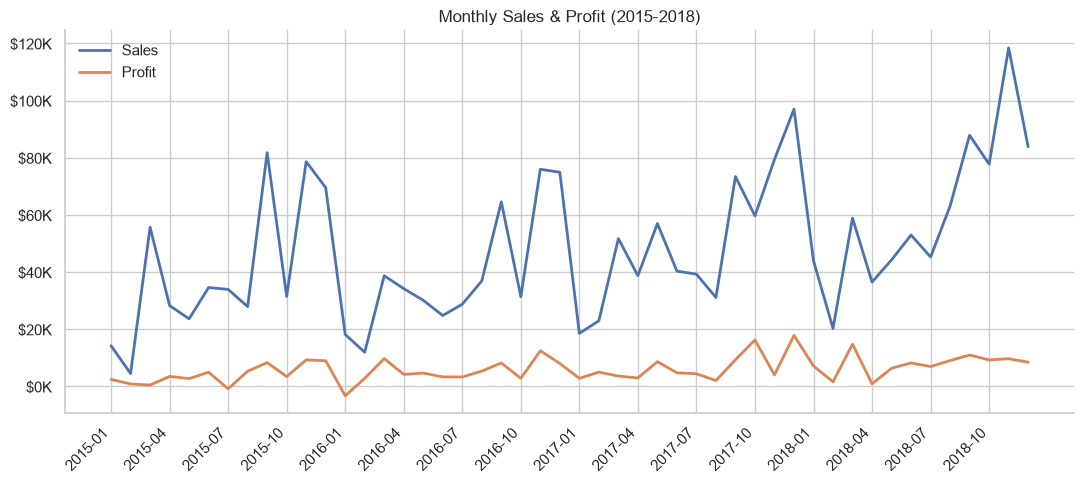

In [15]:
monthly = df.groupby("Order Month")[["Sales", "Profit"]].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["Order Month"], monthly["Sales"], color=PALETTE["sales"], label="Sales", linewidth=2)
ax.plot(monthly["Order Month"], monthly["Profit"], color=PALETTE["accent"], label="Profit", linewidth=2)
ax.set_xticks(monthly["Order Month"][::3])
ax.set_xticklabels(monthly["Order Month"][::3], rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
ax.set_title("Monthly Sales & Profit (2015-2018)")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig("../images/monthly_trend.png", dpi=150)
plt.show()


### 4.6 Customer segment performance


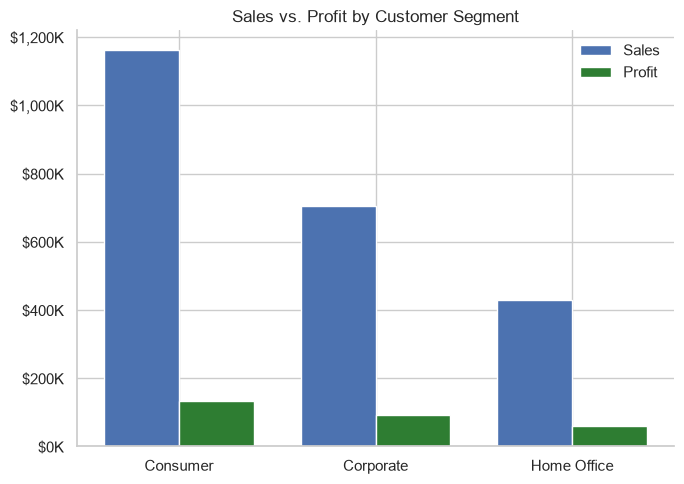

,Sales,Profit,Margin
Segment,,,
Consumer,"$1,161,401","$134,119",11.5%
Corporate,"$706,146","$91,979",13.0%
Home Office,"$429,653","$60,299",14.0%


In [16]:
seg = df.groupby("Segment")[["Sales", "Profit"]].sum()
seg["Margin"] = seg["Profit"] / seg["Sales"]
seg = seg.sort_values("Sales", ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(seg))
width = 0.38
ax.bar(x - width/2, seg["Sales"], width, label="Sales", color=PALETTE["sales"])
ax.bar(x + width/2, seg["Profit"], width, label="Profit", color=PALETTE["profit_pos"])
ax.set_xticks(x)
ax.set_xticklabels(seg.index)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
ax.set_title("Sales vs. Profit by Customer Segment")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig("../images/segment_performance.png", dpi=150)
plt.show()

seg.style.format({"Sales": "${:,.0f}", "Profit": "${:,.0f}", "Margin": "{:.1%}"})


## 5. Business Insights & Recommendations

| # | Finding | Recommendation |
|---|---------|-----------------|
| 1 | **Tables lose $17.7K** on $207K of sales (-8.6% margin), driven by an average discount of 26%. Bookcases and Supplies are also net-negative. | Cap discretionary discounts on Tables/Bookcases at ~15% and route any deeper discount request through a manager approval step. |
| 2 | Profit margin is healthy up to a ~20% discount, then turns negative and keeps falling — discounts above 30% are sold at an average loss. | Set a hard discount ceiling in the pricing/quoting workflow rather than leaving it to rep discretion. |
| 3 | **Central region margin (7.9%) is roughly half of West's (14.9%)** despite Central doing more revenue than South. | Audit Central's discount and shipping-cost patterns specifically — the gap looks structural, not a one-off. |
| 4 | **155 of 793 customers (~20%) are net loss-making** across their full order history, some by several thousand dollars. | Flag these accounts for an account-level pricing review before their next renewal/quote. |
| 5 | Sales spike every **November-December** each year, roughly 2-3x a slow month like February. | Plan inventory and staffing ahead of Q4 rather than reactively; the pattern is consistent across all four years. |
| 6 | Technology and Office Supplies both convert sales to profit at ~17% margin; Furniture sits at 2.5% — dragged down almost entirely by Tables and Bookcases. | Furniture's problem is two sub-categories, not the whole category — don't apply an across-the-board Furniture discount cut. |

## 6. Conclusion

The topline numbers (12.5% margin, steadily growing sales) look healthy, but they hide two concrete, fixable problems: a small set of sub-categories and customer accounts that are quietly loss-making, and a discounting practice with no effective ceiling. Both are addressable with a pricing-policy change rather than a strategic pivot.

**Possible next steps:** turn Section 3's SQL queries into a scheduled report (or a HANA calculation view) so loss-making customers and over-discounted sub-categories surface automatically each month, rather than being found in a one-off analysis like this one.
